In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import contextily as cx

Dataset from https://data.sbb.ch/explore/dataset/passagierfrequenz/export/?disjunctive.kt_ct_cantone&disjunctive.isb_gi&sort=jahr_annee_anno&location=8,46.37157,8.39905&basemap=00c4d6&dataChart=eyJxdWVyaWVzIjpbeyJjaGFydHMiOlt7InR5cGUiOiJsaW5lIiwiZnVuYyI6IkNPVU5UIiwiY29sb3IiOiIjOGRhMGNiIiwic2NpZW50aWZpY0Rpc3BsYXkiOnRydWV9XSwieEF4aXMiOiJjb2RlIiwibWF4cG9pbnRzIjoxMDAsInNvcnQiOiIiLCJjb25maWciOnsiZGF0YXNldCI6InBhc3NhZ2llcmZyZXF1ZW56Iiwib3B0aW9ucyI6eyJkaXNqdW5jdGl2ZS5rdF9jdF9jYW50b25lIjp0cnVlLCJkaXNqdW5jdGl2ZS5pc2JfZ2kiOnRydWUsInNvcnQiOiJqYWhyX2FubmVlX2Fubm8ifX19XSwidGltZXNjYWxlIjoiIiwiZGlzcGxheUxlZ2VuZCI6dHJ1ZSwiYWxpZ25Nb250aCI6dHJ1ZX0%3D

In [2]:
path_frequency_users = Path("../data/passagierfrequenz.csv")

df = pd.read_csv(path_frequency_users, sep=";")

df.head()

,Code_Codice,UIC,Bahnhof_Gare_Stazione,Kt_Ct_Cantone,ISB_GI,Jahr_Annee_Anno,DTV_TJM_TGM,DWV_TMJO_TFM,DNWV_TMJNO_TMGNL,EVU_EF_ITF,Bemerkung,Bemerkungen,Note,Bemerkungen.1,LOD,geopos
0,ALT,8506319.0,Altstätten SG,SG,SBB,2024,2700.0,3100.0,1900.0,"SBB, SOB, Thurbo",NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.374234807062635, 9.556519883564428"
1,ALTD,8503211.0,Altendorf,SZ,SBB,2024,760.0,860.0,530.0,"SBB, SOB",NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.19396706593207, 8.822905848209773"
2,AND,8505165.0,Andermatt,UR,MGB,2022,2900.0,2800.0,3300.0,MGB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"46.636890087679205, 8.593280416936754"
3,BAA,8502206.0,Baar,ZG,SBB,2018,8900.0,10700.0,5000.0,SBB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.19536403756802, 8.523271537389258"
4,BAAL,8515993.0,Baar Lindenpark,ZG,SBB,2023,1200.0,1500.0,530.0,SBB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.18313669446829, 8.517058460139534"


In [3]:
df = df.rename(columns={
    'Code_Codice': 'code',
    'UIC': 'uic',
    'Bahnhof_Gare_Stazione': 'station_name',
    'Kt_Ct_Cantone': 'canton',
    'ISB_GI': 'operator',
    'Jahr_Annee_Anno': 'year',
    'DTV_TJM_TGM': 'avg_users_per_day',
    'DWV_TMJO_TFM': 'avg_users_working_day',
    'DNWV_TMJNO_TMGNL': 'avg_users_non_working_day', 
    'EVU_EF_ITF': 'train_operators',
    'BemerkungBemerkungenNote': 'note',
    'Bemerkungen.1': 'note_2',
    'LOD': 'lod_url',
    'geopos': 'geopos'
})
print(df.columns.tolist())

['code', 'uic', 'station_name', 'canton', 'operator', 'year', 'avg_users_per_day', 'avg_users_working_day', 'avg_users_non_working_day', 'train_operators', 'Bemerkung', 'Bemerkungen', 'Note', 'note_2', 'lod_url', 'geopos']


In [4]:
df = df[df['year'] == 2024].copy()


In [5]:
# National top 10 stations
top10_national = (
    df
    .sort_values('avg_users_per_day', ascending=False)
    .head(10)
    [['station_name', 'canton', 'operator', 'avg_users_per_day']]
)

# Top 3 per canton 
top_per_canton = (
    df
    .sort_values(['canton', 'avg_users_per_day'], ascending=[True, False])
    .groupby('canton')
    .head(3)
    [['station_name', 'canton', 'operator', 'avg_users_per_day']]
)



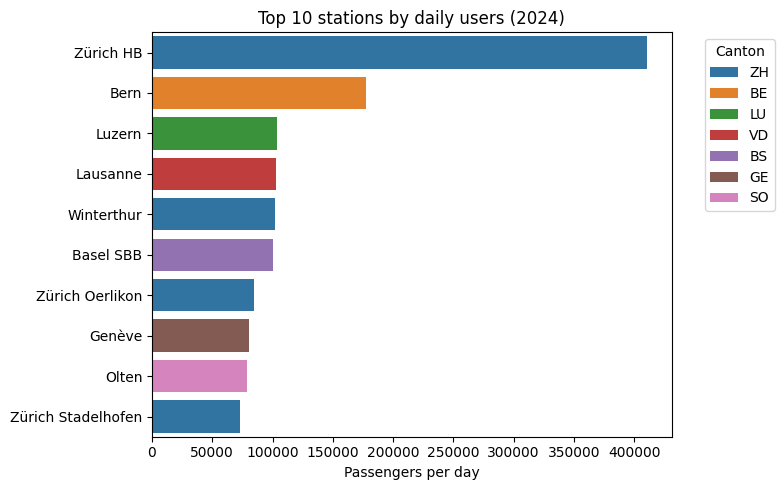

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10_national,
    x='avg_users_per_day',
    y='station_name',
    hue='canton',
    dodge=False
)
plt.xlabel('Passengers per day')
plt.ylabel('')
plt.title('Top 10 stations by daily users (2024)')
plt.legend(title='Canton', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

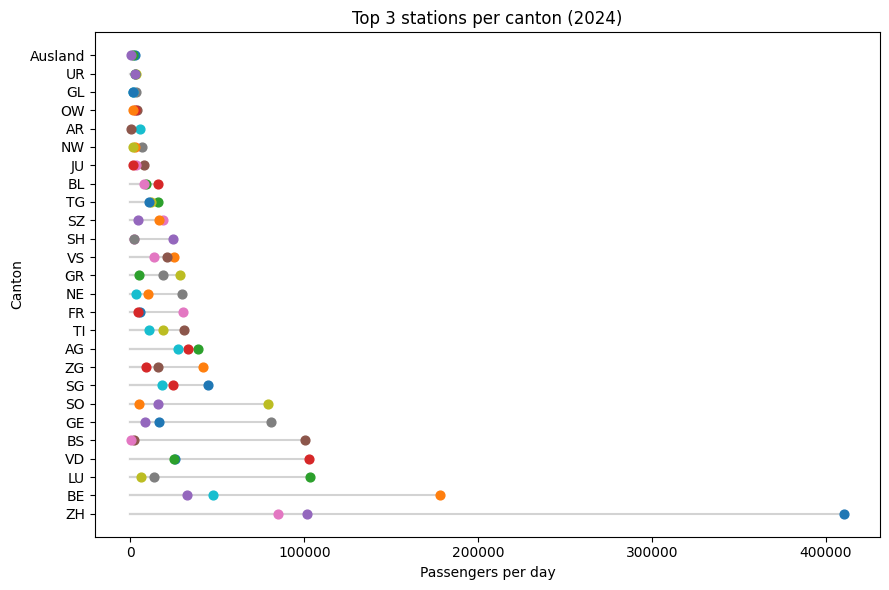

In [7]:
tmp = top_per_canton.sort_values('avg_users_per_day', ascending=False)

plt.figure(figsize=(9, 6))
for _, row in tmp.iterrows():
    plt.plot(
        [0, row['avg_users_per_day']],
        [row['canton'], row['canton']],
        color='lightgray',
        zorder=1
    )
    plt.scatter(
        row['avg_users_per_day'],
        row['canton'],
        s=40,
        label=row['station_name'],
        zorder=2
    )

plt.xlabel('Passengers per day')
plt.ylabel('Canton')
plt.title('Top 3 stations per canton (2024)')
plt.tight_layout()
plt.show()

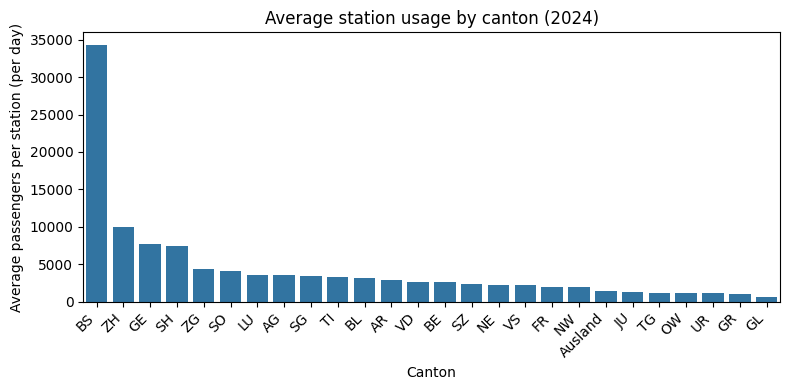

In [8]:
mean_by_canton = (
    df.groupby('canton')['avg_users_per_day']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=mean_by_canton,
    x='canton',
    y='avg_users_per_day'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average passengers per station (per day)')
plt.xlabel('Canton')
plt.title('Average station usage by canton (2024)')
plt.tight_layout()
plt.show()


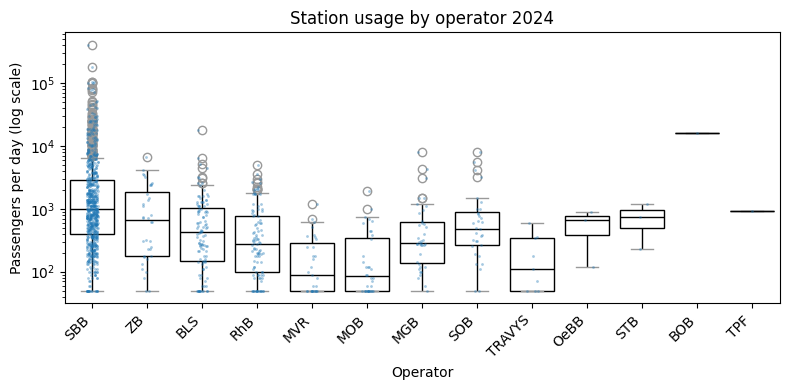

In [9]:
plt.figure(figsize=(8, 4))

# Boxplot per operator
sns.boxplot(
    data=df,
    x='operator',
    y='avg_users_per_day',
    color='white',
    showcaps=True,
    boxprops={'edgecolor': 'black'},
    medianprops={'color': 'black'},
    whiskerprops={'color': 'black'}
)

# Jittered points on top
sns.stripplot(
    data=df,
    x='operator',
    y='avg_users_per_day',
    color='tab:blue',
    alpha=0.4,
    size=2,
    jitter=True
)

plt.yscale('log')
plt.xlabel('Operator')
plt.ylabel('Passengers per day (log scale)')
plt.title('Station usage by operator 2024')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

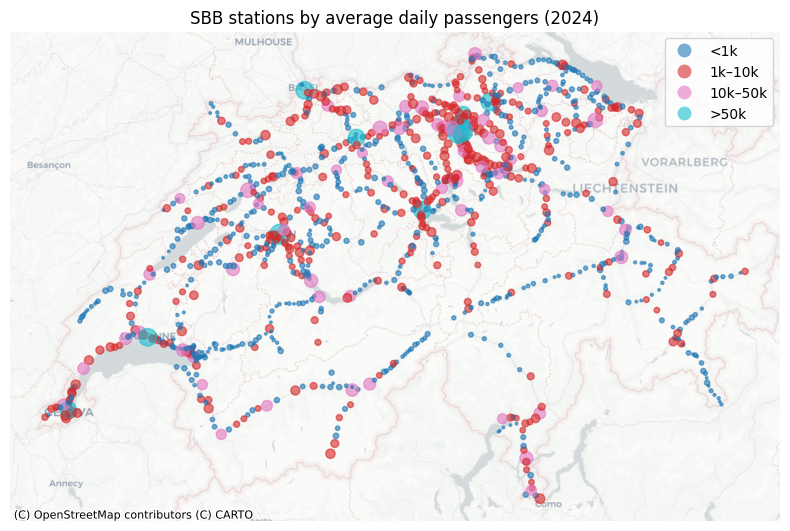

In [10]:
# Define size classes
bins = [0, 1000, 10000, 50000, np.inf]
labels = ['<1k', '1k–10k', '10k–50k', '>50k']
df['size_class'] = pd.cut(df['avg_users_per_day'], bins=bins, labels=labels, right=False)


# Split "lat, lon"
coords = df['geopos'].str.split(',', expand=True).astype(float)
df['lat'] = coords[0]
df['lon'] = coords[1]

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
).to_crs("EPSG:3857") 

# Size for circles: function of usage (tune scaling factor)
gdf['circle_size'] = (gdf['avg_users_per_day'] ** 0.5) * 0.5

fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    ax=ax,
    column='size_class',
    markersize=gdf['circle_size'],
    legend=True,
    alpha=0.6
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron 
)

ax.set_axis_off()
plt.title(f"SBB stations by average daily passengers (2024)")
plt.tight_layout()
plt.show()


In [11]:
#manually defined list of IC hubs 
ic_hubs = [
    'Zürich HB', 'Genève', 'Basel SBB', 'Bern', 'Luzern',
    'Lausanne', 'Winterthur', 'St. Gallen', 'Lugano', 'Biel/Bienne'
]

df['is_ic_hub'] = df['station_name'].isin(ic_hubs)

# Summary statistics
summary_ic = (
    df
    .groupby('is_ic_hub')['avg_users_per_day']
    .describe()
)

print(summary_ic)

            count           mean            std      min      25%       50%  \
is_ic_hub                                                                     
False      1146.0    2503.658813    6458.034516     49.0    242.5     685.0   
True         10.0  120010.000000  110381.746176  30600.0  55625.0  101150.0   

                75%       max  
is_ic_hub                      
False        1700.0   84600.0  
True       103325.0  410700.0  


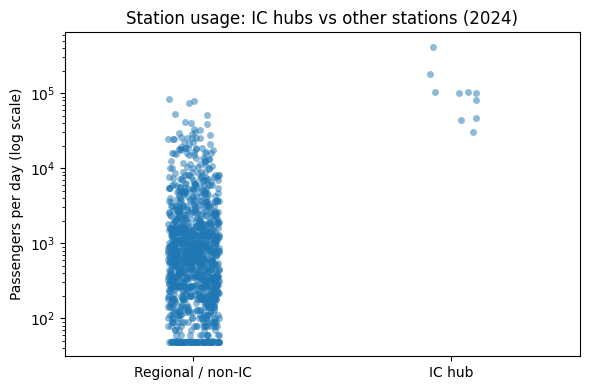

In [12]:
plt.figure(figsize=(6, 4))
sns.stripplot(
    data=df,
    x='is_ic_hub',
    y='avg_users_per_day',
    jitter=True,
    alpha=0.5
)

plt.yscale('log')  
plt.xticks([0, 1], ['Regional / non‑IC', 'IC hub'])
plt.ylabel('Passengers per day (log scale)')
plt.xlabel('')
plt.title(f"Station usage: IC hubs vs other stations ({2024})")

plt.tight_layout()
plt.show()
